In [21]:
# ==============================================================================
# 0. LIBRARY INITIALIZATION
# ==============================================================================

%pip install pgmpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# PGMpy Imports
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, HillClimbSearch, BDeu
from pgmpy.inference import VariableElimination

# Metrics & Utilities
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm # Visualization utility for long-running loops
import random

# --- Reproducibility Setup ---
# Fix random seeds to ensure deterministic behavior across runs.
SEED = 1
np.random.seed(SEED)
random.seed(SEED)

# ==============================================================================
# 1. DATA LOADING AND STATE MAPPING
# ==============================================================================
# Intent: Ingest processed datasets and harmonize state space for the Bayesian Network.
# Logic: Bayesian Networks require a fixed vocabulary of states (values) for each node.
#        We must scan BOTH training and test data to define the full domain of valid states.

DATA_PATH = Path('../processed_data')
TRAIN_FILE = DATA_PATH / 'atp_matches_training.csv'
TEST_FILE = DATA_PATH / 'atp_matches_test_2024.csv'

try:
    # --- Load Datasets ---
    df_train = pd.read_csv(TRAIN_FILE)
    df_test = pd.read_csv(TEST_FILE)
    
    # Enforce string typing for categorical processing.
    # Logic: pgmpy expects discrete states (strings), not numerical types, for DiscreteBN.
    for col in df_train.columns:
        df_train[col] = df_train[col].astype(str)
        df_test[col] = df_test[col].astype(str)

    print(f"Data Loaded. Train: {len(df_train)} | Test: {len(df_test)}")

    # --- Domain Initialization (State Dictionary) ---
    # Construct a comprehensive registry of all possible values per variable.
    # Prevents 'ValueError' during inference if the Test set contains a state unseen in Training.
    state_names = {}
    all_data = pd.concat([df_train, df_test])
    
    for col in all_data.columns:
        # Aggregating unique values creates the complete sample space for the node.
        unique_states = sorted(all_data[col].unique().tolist())
        state_names[col] = unique_states
        
    print("\nState Dictionary created. Example 'Surface' states:", state_names['Surface'])

except FileNotFoundError:
    print("Error: Files not found. Run data_preparation.ipynb first.")

Note: you may need to restart the kernel to use updated packages.
Data Loaded. Train: 25648 | Test: 2932

State Dictionary created. Example 'Surface' states: ['Carpet', 'Clay', 'Grass', 'Hard']



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# ==============================================================================
# 2. MODEL 1: EXPERT KNOWLEDGE
# ==============================================================================
# Intent: Construct a Bayesian Network DAG using expert domain knowledge.
# Logic: Manually define dependencies: Context -> Performance Stats -> Match Outcome.

print("Defining Model 1 (Expert)...")

model_1 = DiscreteBayesianNetwork()

# A. Causal Dependencies (Context -> Stats)
# Encode physical and environmental constraints.
# Logic: Surface speed affects serve efficacy (Ace/SvPt); Height dictates serve angle.
model_1.add_edges_from([
    ('Surface', 'Cat_Ace'),
    ('Surface', 'Cat_SvPt'),
    ('Surface', 'Cat_DF'),
    ('Tourney_Level', 'Cat_DF'),
    ('Cat_Ht', 'Cat_Ace'),
    ('Cat_Ht', 'Cat_SvPt'),
    ('Cat_Age', 'Fav_Recent_Form'),
    ('Fav_Hand', 'Hand_Matchup')
])

# B. Predictors -> Target
# Define direct parents of the target variable.
predictors = [
    'Cat_Rank', 'Cat_SvPt', 'Hand_Matchup',
    'Fav_Recent_Form', 'Fav_On_Worst_Surface',
    'Cat_Ace', 'Cat_DF'
]

# Converge evidence nodes to the single classification target.
for p in predictors:
    model_1.add_edge(p, 'Target_Win')

print(f"Model 1 Structure: {len(model_1.nodes())} nodes, {len(model_1.edges())} edges")

Defining Model 1 (Expert)...
Model 1 Structure: 13 nodes, 15 edges


In [23]:
# ==============================================================================
# 3. MODEL 2: NAIVE BAYES
# ==============================================================================
# Intent: Implement standard Naive Bayes architecture for baseline benchmarking.
# Logic: Assumes all features are conditionally independent given the Target (Class).
#        Structure: Target (Parent) -> All Features (Children).

print("Defining Model 2 (Naive Bayes)...")

model_2 = DiscreteBayesianNetwork()
target = 'Target_Win'

# --- Define Topology ---
# Construct "star" topology where Target connects to every feature.
# Logic: Establishes P(Feature|Class) relationships for generative classification.
for col in df_train.columns:
    if col != target:
        model_2.add_edge(target, col)

print(f"Model 2 Structure: {len(model_2.nodes())} nodes, {len(model_2.edges())} edges")

Defining Model 2 (Naive Bayes)...
Model 2 Structure: 13 nodes, 12 edges


In [24]:
# ==============================================================================
# 4. MODEL 3: VARIANT (No Physical Links)
# ==============================================================================
# Intent: Construct "Ablation Study" variant.
# Logic: Simplify network by pruning physical attribute dependencies.
#        Tests hypothesis that 'Height' is redundant when 'Ace' and 'Service' metrics are already observed.

print("Defining Model 3 (Variant)...")

# Inherit baseline structure from Expert Model (Model 1).
edges_3 = list(model_1.edges())

# --- Pruning Strategy ---
# Remove causal links between Height and Serve metrics.
# Logic: Isolate variables to verify if explicit physical modeling improves accuracy or adds noise.
if ('Cat_Ht', 'Cat_Ace') in edges_3: edges_3.remove(('Cat_Ht', 'Cat_Ace'))
if ('Cat_Ht', 'Cat_SvPt') in edges_3: edges_3.remove(('Cat_Ht', 'Cat_SvPt'))

model_3 = DiscreteBayesianNetwork(edges_3)
# Ensure all dataset columns are registered as nodes, even if disconnected.
model_3.add_nodes_from(df_train.columns)

print(f"Model 3 Structure: {len(model_3.nodes())} nodes, {len(model_3.edges())} edges")

Defining Model 3 (Variant)...
Model 3 Structure: 13 nodes, 13 edges


In [25]:
# ==============================================================================
# 5. MODEL 4: STRUCTURE LEARNING (Data Driven)
# ==============================================================================
# Intent: Discover optimal network topology using algorithmic search.
# Logic: Utilize Hill Climbing to navigate the space of possible DAGs, optimizing for the BDeu score.
#        This approach ignores expert bias in favor of statistical dependencies found in the data.

print("Learning Model 4 structure (Hill Climbing)...")

# --- Configuration ---
# Define scoring metric.
# BDeu (Bayesian Dirichlet equivalent uniform) penalizes complexity to prevent overfitting.
# 'equivalent_sample_size': Controls the weight of the prior (uniform distribution).
scorer = BDeu(df_train, equivalent_sample_size=10)

# Initialize search heuristic.
# Hill Climbing performs local changes (add/delete/reverse edge) to maximize the score.
hc = HillClimbSearch(df_train)

# --- Execution ---
# Run the structure learning algorithm.
# 'max_iter': Limit search steps to ensure termination.
# 'epsilon': Threshold for score improvement (stop if gain is negligible).
best_structure = hc.estimate(scoring_method=scorer, max_iter=50, epsilon=1e-4)

# Instantiate the learned model.
model_4 = DiscreteBayesianNetwork(best_structure.edges())
# Register all nodes (handles isolated nodes if the learner found no significant dependencies).
model_4.add_nodes_from(df_train.columns)

print(f"Model 4 Learned: {len(model_4.edges())} edges")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface': 'C', 'Fav_Recent_Form': 'C', 'Target_Win': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface': 'C', 'Fav_Recent_Form': 'C', 'Target_Win': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface'

Learning Model 4 structure (Hill Climbing)...


  0%|          | 0/50 [00:00<?, ?it/s]

Model 4 Learned: 27 edges


In [26]:
# ==============================================================================
# 5.5 PARAMETER LEARNING (FITTING)
# ==============================================================================
# Intent: Quantify network dependencies by calculating Conditional Probability Distributions (CPDs).
# Logic: Use Maximum Likelihood Estimation (MLE) on training data to learn probability tables for each node.

print("Training models (Parameter Learning)...")

# Define evaluation cohort.
models_list = [model_1, model_2, model_3, model_4]
model_names = ["1. Expert", "2. Naive Bayes", "3. Variant", "4. Learned"]

for name, model in zip(model_names, models_list):
    print(f"Fitting {name}...")
    try:
        # --- Compute CPDs ---
        # Learn probabilities from frequency counts.
        # Critical: 'state_names' argument injects the full domain vocabulary (Train + Test).
        #           This prevents model failure when encountering valid states that were absent in the training split.
        model.fit(
            data=df_train, 
            estimator=MaximumLikelihoodEstimator, 
            state_names=state_names
        )
        
        # --- Integrity Check ---
        # Verify mathematical validity of the network (e.g., all probabilities sum to 1.0).
        if model.check_model():
            print(f"  -> {name}: Check OK. CPDs generated.")
        else:
            print(f"  -> {name}: Check failed.")
            
    except Exception as e:
        print(f"  -> Error fitting {name}: {e}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface': 'C', 'Fav_Recent_Form': 'C', 'Target_Win': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface': 'C', 'Fav_Recent_Form': 'C', 'Target_Win': 'C'}


Training models (Parameter Learning)...
Fitting 1. Expert...
  -> 1. Expert: Check OK. CPDs generated.
Fitting 2. Naive Bayes...
  -> 2. Naive Bayes: Check OK. CPDs generated.
Fitting 3. Variant...


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface': 'C', 'Fav_Recent_Form': 'C', 'Target_Win': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Surface': 'C', 'Tourney_Level': 'C', 'Cat_Rank': 'C', 'Cat_Age': 'C', 'Cat_Ht': 'C', 'Fav_Hand': 'C', 'Hand_Matchup': 'C', 'Cat_Ace': 'C', 'Cat_DF': 'C', 'Cat_SvPt': 'C', 'Fav_On_Worst_Surface': 'C', 'Fav_Recent_Form': 'C', 'Target_Win': 'C'}


  -> 3. Variant: Check OK. CPDs generated.
Fitting 4. Learned...
  -> 4. Learned: Check OK. CPDs generated.


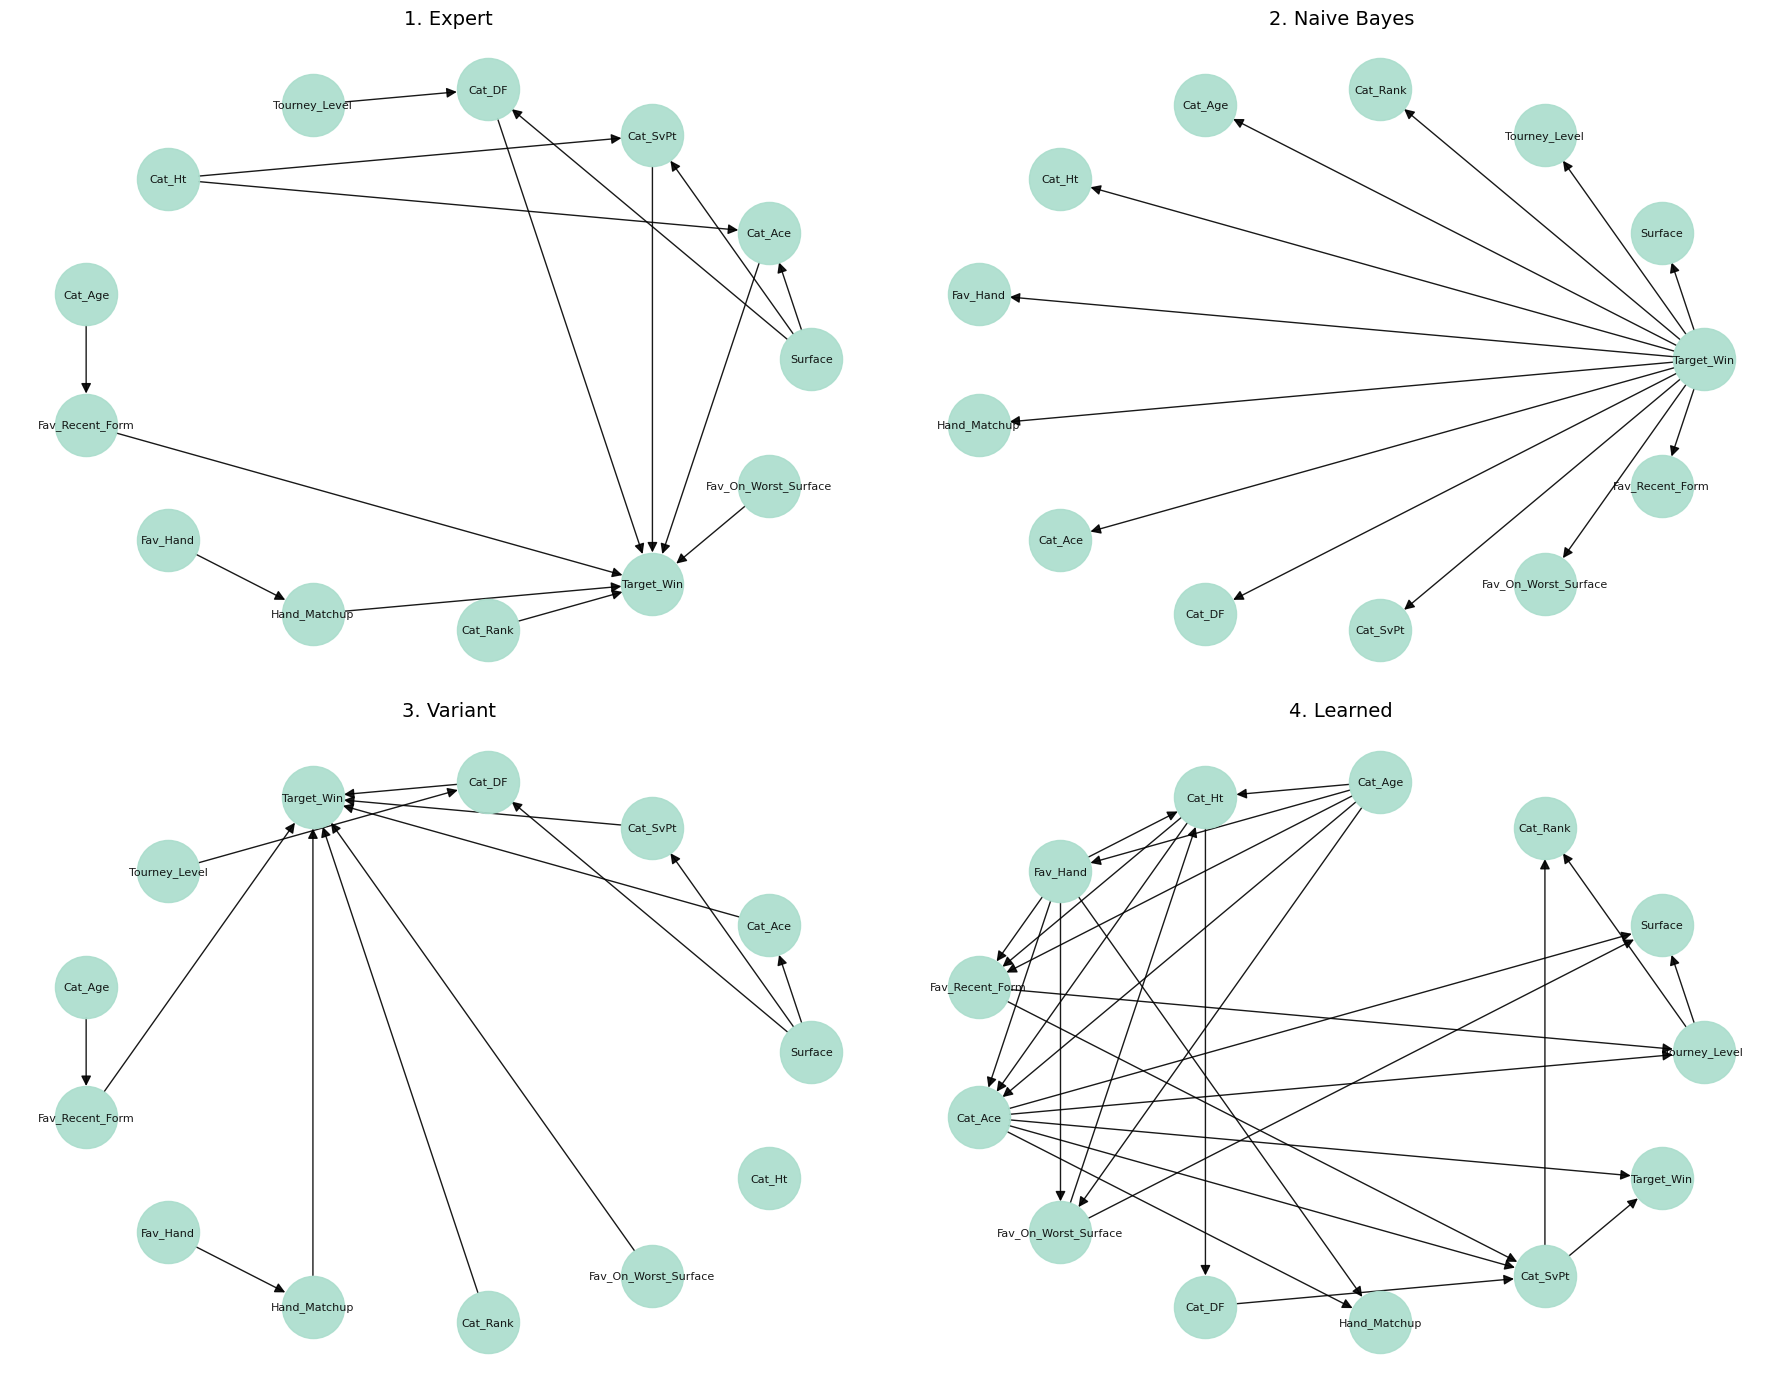

In [27]:
# ==============================================================================
# 6. VISUALIZATION
# ==============================================================================
# Intent: Visually compare the structural topology of all trained Bayesian Networks.
# Logic: Direct inspection of the DAG (Directed Acyclic Graph) reveals causal assumptions (Expert) vs statistical dependencies (Learned).

models_map = {
    "1. Expert": model_1,
    "2. Naive Bayes": model_2,
    "3. Variant": model_3,
    "4. Learned": model_4
}

# Initialize 2x2 grid for side-by-side comparison.
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (name, model) in enumerate(models_map.items()):
    try:
        # --- Graph Layout ---
        # Compute node positions using circular arrangement for readability.
        pos = nx.circular_layout(model)
        
        # --- Rendering ---
        # Draw nodes and directed edges.
        # Visual cues: Standardized node size/color for consistency across subplots.
        nx.draw_networkx(
            model, pos, ax=axes[i],
            with_labels=True, node_size=2000, 
            node_color="#aaddcc", font_size=8, 
            arrowsize=15, alpha=0.9
        )
        axes[i].set_title(name, fontsize=14)
        axes[i].axis('off') # Hide axis coordinates (irrelevant for network graphs)
    except Exception as e:
        print(f"Error plotting {name}: {e}")

plt.tight_layout()
plt.show()

In [28]:
# ==============================================================================
# 7. FINAL EVALUATION & NARRATIVE SCENARIOS
# ==============================================================================
# Intent: Validate model performance on unseen future data (2024) and audit reasoning via specific edge cases.
from tqdm import tqdm

print("\n" + "="*60)
print("1. FIELD VALIDATION: 2024 SEASON")
print("="*60)

# --- A. Accuracy Calculation (Robust Method) ---
# Intent: Benchmark models against Ground Truth.
# Logic: Use row-by-row processing to simulate real-time prediction context.
test_clean = df_test.dropna()
y_true = test_clean['Target_Win'].tolist()

inference_engines = {}
results = {}

for name, model in models_map.items():
    print(f"\nTesting {name}...")
    
    try:
        # Initialize Exact Inference Engine.
        # Logic: Prepares the DAG for probability propagation.
        infer = VariableElimination(model)
        inference_engines[name] = infer
        
        y_pred = []
        # Progress bar for visual feedback during computationally intensive inference.
        for _, row in tqdm(test_clean.iterrows(), total=len(test_clean), desc="  Predicting", leave=False):
            
            # Extract observable features (Evidence).
            evidence = row.to_dict()
            if 'Target_Win' in evidence: del evidence['Target_Win']
            
            # Filter evidence to match specific model topology.
            # Logic: Passing nodes that do not exist in the specific model variant raises KeyErrors.
            valid_evidence = {k: v for k, v in evidence.items() if k in model.nodes()}
            
            try:
                # Compute Maximum A Posteriori (MAP) assignment.
                # Query: "Given observations, what is the most probable state of Target_Win?"
                map_res = infer.map_query(variables=['Target_Win'], evidence=valid_evidence, show_progress=False)
                y_pred.append(map_res['Target_Win'])
            except:
                # Fail-safe mechanism.
                # Logic: Default to majority class ('Win') if inference diverges or encounters zero-probability states.
                y_pred.append('Win') 
        
        # Calculate Aggregated Metrics.
        acc = accuracy_score(y_true, y_pred)
        results[name] = acc
        print(f"  -> Final Accuracy: {acc:.2%}")
        
    except Exception as e:
        print(f"  -> Error during testing: {e}")

# Print Leaderboard
# Rank models by predictive power on the 2024 test set.
print("\n" + "-"*40)
print("MODEL LEADERBOARD (2024 Accuracy)")
print("-"*40)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<25}: {acc:.2%}")


# --- B. Narrative Scenarios (Qualitative Analysis) ---
print("\n" + "="*60)
print("2. SCENARIO ANALYSIS: THE MODEL'S 'BRAIN'")
print("="*60)
print("We interrogate the models on real tennis situations to understand their reasoning.\n")

# Define semantic test cases.
# Intent: Stress-test models against domain intuition (e.g., impact of surface mismatch or bad form).
scenarios = [
    {
        "title": "The Favorite's Nightmare (Surface)",
        "desc": "A 'Strong' Favorite (Rank++) forced to play on their worst surface. Does the win probability drop?",
        "evidence": {'Cat_Rank': 'Strong', 'Fav_On_Worst_Surface': 'Yes'}
    },
    {
        "title": "Negative 'Momentum' (Cold Form)",
        "desc": "A 'Moderate' Favorite arriving in terrible form (Cold). Is an upset likely?",
        "evidence": {'Cat_Rank': 'Moderate', 'Fav_Recent_Form': 'Cold'}
    },
    {
        "title": "Pressure Factor (Slam vs ATP 250)",
        "desc": "Balanced match. Does the favorite handle pressure better in a Slam (Level=G) vs an ATP 250 (Level=A)?",
        "evidence_a": {'Cat_Rank': 'Balanced', 'Tourney_Level': 'G'}, # Grand Slam
        "evidence_b": {'Cat_Rank': 'Balanced', 'Tourney_Level': 'A'}  # ATP 250
    },
    {
        "title": "Service Dominance",
        "desc": "How much does serving well (High) vs serving poorly (Low) matter for a clear favorite?",
        "evidence_a": {'Cat_Rank': 'Strong', 'Cat_SvPt': 'High'},
        "evidence_b": {'Cat_Rank': 'Strong', 'Cat_SvPt': 'Low'}
    }
]

# Helper function to query probability
def get_win_prob(engine, ev):
    """
    Extract posterior probability for the 'Win' state.
    Returns: Float probability (0.0 to 1.0). Returns 0.0 on inference failure.
    """
    try:
        q = engine.query(['Target_Win'], evidence=ev, show_progress=False)
        # Identify index of the 'Win' state in the DiscreteDistribution
        idx = q.state_names['Target_Win'].index('Win')
        return q.values[idx]
    except:
        return 0.0

# Execute Scenarios
for sc in scenarios:
    print(f"SCENARIO: {sc['title']}")
    print(f"   \"{sc['desc']}\"")
    
    # Determine Logic: Comparative (A/B) vs Single-Point Analysis
    if 'evidence_b' in sc:
        # Compare impact of changing a single variable (e.g., Tourney Level).
        print(f"   {'Model':<25} | {'Case A':<10} | {'Case B':<10} | {'Delta'}")
        print("   " + "-"*60)
        for name, infer in inference_engines.items():
            p_a = get_win_prob(infer, sc['evidence_a'])
            p_b = get_win_prob(infer, sc['evidence_b'])
            print(f"   {name:<25} | {p_a:.1%}      | {p_b:.1%}      | {p_a-p_b:+.1%}")
    else:
        # Evaluate absolute probability given specific constraints.
        print(f"   {'Model':<25} | {'Win Probability'}")
        print("   " + "-"*45)
        for name, infer in inference_engines.items():
            p = get_win_prob(infer, sc['evidence'])
            print(f"   {name:<25} | {p:.1%}")
    
    print("\n")


1. FIELD VALIDATION: 2024 SEASON

Testing 1. Expert...


  -> Final Accuracy: 91.37%

Testing 2. Naive Bayes...


  Predicting:  66%|██████▋   | 1944/2932 [00:05<00:02, 384.02it/s]c:\Users\Francesco\Desktop\Magistrale\Primo anno\FUNDAMENTALS OF AI\Modulo 3\Fundamentals_Of_AI_MOD3\.venv\Lib\site-packages\pgmpy\factors\discrete\DiscreteFactor.py:489: RuntimeWarning: invalid value encountered in divide
  phi.values = phi.values / (phi.values.sum())


  -> Final Accuracy: 90.01%

Testing 3. Variant...


  -> Final Accuracy: 91.37%

Testing 4. Learned...


  -> Final Accuracy: 91.51%

----------------------------------------
MODEL LEADERBOARD (2024 Accuracy)
----------------------------------------
4. Learned               : 91.51%
1. Expert                : 91.37%
3. Variant               : 91.37%
2. Naive Bayes           : 90.01%

2. SCENARIO ANALYSIS: THE MODEL'S 'BRAIN'
We interrogate the models on real tennis situations to understand their reasoning.

SCENARIO: The Favorite's Nightmare (Surface)
   "A 'Strong' Favorite (Rank++) forced to play on their worst surface. Does the win probability drop?"
   Model                     | Win Probability
   ---------------------------------------------
   1. Expert                 | 64.0%
   2. Naive Bayes            | 66.4%
   3. Variant                | 64.1%
   4. Learned                | 70.5%


SCENARIO: Negative 'Momentum' (Cold Form)
   "A 'Moderate' Favorite arriving in terrible form (Cold). Is an upset likely?"
   Model                     | Win Probability
   ------------------------

In [29]:
# ==============================================================================
# 8. DEEP DIVE: SURFACE IMPACT ANALYSIS
# ==============================================================================
# Intent: Isolate the 'Surface' variable to audit model reasoning against tennis physics.
# Logic: Perform 'What-If' analysis across the three main surfaces (Clay, Hard, Grass).

surfaces = ['Clay', 'Hard', 'Grass']

# Ensure inference engines are available
if not inference_engines:
    print("Error: Inference engines not initialized. Run Block 7 first.")
else:
    print("\n" + "="*60)
    print("3. SURFACE DEEP DIVE: CLAY vs HARD vs GRASS")
    print("="*60)

    # --- Query A: Probability of High ACE count ---
    # Intent: Validate physical constraints.
    # Logic: Tall players should statistically produce more Aces on fast surfaces (Grass) than slow ones (Clay).
    print("\n--- Query A: Probability of HIGH ACE Count (Tall Player) ---")
    print(f"{'Model':<25} | {'Clay':<10} | {'Hard':<10} | {'Grass':<10}")
    print("-" * 65)

    for name, infer in inference_engines.items():
        probs = []
        for surf in surfaces:
            try:
                q = infer.query(
                    variables=['Cat_Ace'],
                    evidence={
                        'Surface': surf,
                        'Cat_Ht': 'High',       # Tall Player
                        'Cat_Rank': 'Strong'    # Strong Favorite
                    },
                    show_progress=False
                )
                # Extract probability for 'High' Ace count state
                idx = q.state_names['Cat_Ace'].index('High')
                probs.append(q.values[idx])
            except:
                # Fallback for states not observed in training (Zero-fill)
                probs.append(0.0)
                
        print(f"{name:<25} | {probs[0]:.1%}     | {probs[1]:.1%}     | {probs[2]:.1%}")


    # --- Query B: Probability of Holding SERVICE (High %) ---
    # Intent: Assess surface dominance factors.
    # Logic: Determine where "Serve Dominance" is most prevalent in evenly matched games.
    print("\n--- Query B: Probability of HIGH SERVICE % (Balanced Match) ---")
    print(f"{'Model':<25} | {'Clay':<10} | {'Hard':<10} | {'Grass':<10}")
    print("-" * 65)

    for name, infer in inference_engines.items():
        probs = []
        for surf in surfaces:
            try:
                q = infer.query(
                    variables=['Cat_SvPt'], 
                    evidence={
                        'Surface': surf,
                        'Cat_Rank': 'Balanced'
                    },
                    show_progress=False
                )
                # Extract probability for 'High' Service % state
                idx = q.state_names['Cat_SvPt'].index('High')
                probs.append(q.values[idx])
            except:
                probs.append(0.0)
                
        print(f"{name:<25} | {probs[0]:.1%}     | {probs[1]:.1%}     | {probs[2]:.1%}")


    # --- Query C: UPSET Risk (Probability of Loss) ---
    # Intent: Quantify volatility.
    # Logic: Does playing on specific surfaces increase the variance (risk of loss) for a Strong Favorite?
    print("\n--- Query C: UPSET RISK (Favorite Loss) by Surface ---")
    print(f"{'Model':<25} | {'Clay':<10} | {'Hard':<10} | {'Grass':<10}")
    print("-" * 65)

    for name, infer in inference_engines.items():
        probs = []
        for surf in surfaces:
            try:
                q = infer.query(
                    variables=['Target_Win'],
                    evidence={
                        'Surface': surf,
                        'Cat_Rank': 'Strong',
                        'Hand_Matchup': 'Opposite'
                    },
                    show_progress=False
                )
                # Extract probability for 'Loss' state (Inverse of Win)
                idx = q.state_names['Target_Win'].index('Loss')
                probs.append(q.values[idx])
            except:
                probs.append(0.0)
                
        print(f"{name:<25} | {probs[0]:.1%}     | {probs[1]:.1%}     | {probs[2]:.1%}")


3. SURFACE DEEP DIVE: CLAY vs HARD vs GRASS

--- Query A: Probability of HIGH ACE Count (Tall Player) ---
Model                     | Clay       | Hard       | Grass     
-----------------------------------------------------------------
1. Expert                 | 47.0%     | 61.4%     | 64.1%
2. Naive Bayes            | 33.3%     | 33.5%     | 33.5%
3. Variant                | 23.3%     | 35.1%     | 38.8%
4. Learned                | 48.4%     | 64.0%     | 68.0%

--- Query B: Probability of HIGH SERVICE % (Balanced Match) ---
Model                     | Clay       | Hard       | Grass     
-----------------------------------------------------------------
1. Expert                 | 33.2%     | 33.6%     | 31.9%
2. Naive Bayes            | 28.6%     | 29.4%     | 29.2%
3. Variant                | 33.2%     | 33.6%     | 32.1%
4. Learned                | 25.2%     | 26.2%     | 23.2%

--- Query C: UPSET RISK (Favorite Loss) by Surface ---
Model                     | Clay       | Hard 

In [30]:
# =============================================================================
# PHASE 6: ADVANCED COMPARATIVE ANALYSIS (ENRICHMENT PLAN)
# =============================================================================
# Intent: Stress-test models against complex, domain-specific scenarios to evaluate reasoning capabilities.
# Logic: Beyond raw accuracy, we must verify if models capture subtle tennis dynamics (e.g., surface anomalies, pressure situations).

print("\n--- STARTING ADVANCED COMPARATIVE ANALYSIS ---")

def query_all_models(evidence_dict, target_var='Target_Win', target_state='Win'):
    """
    Execute inference across all registered Bayesian Networks.
    
    Inputs: 
        evidence_dict (dict): Observed states (e.g., {'Surface': 'Clay'}).
        target_var (str): Variable to predict.
        target_state (str): Specific state to probability (e.g., 'Win').
        
    Purpose: Standardize model interrogation and handle exception management for unseen states.
    """
    print(f"\nEVIDENCE SCENARIO: {evidence_dict}")
    print(f"{'Model Name':<30} | P({target_var} = {target_state})")
    print("-" * 65)
    
    # Validation: Ensure inference engines are initialized
    if 'inference_engines' not in globals():
        print("Error: 'inference_engines' dictionary not found. Please run the Modeling & Evaluation cells first.")
        return

    # Iterate over the dictionary of inference engines
    for name, infer in inference_engines.items():
        try:
            # Execute Variable Elimination query
            q = infer.query(variables=[target_var], evidence=evidence_dict, show_progress=False)
            
            # Extract probability for the target state
            state_idx = q.state_names[target_var].index(target_state)
            probability = q.values[state_idx]
            
            print(f"{name:<30} | {probability:.4f} ({probability*100:.1f}%)")
        except Exception as e:
            # Handle data sparsity (e.g., specific evidence combination never observed in training)
            print(f"{name:<30} | N/A (State combination not observed or invalid)")

# ---------------------------------------------------------
# SCENARIO 1: The "Aging Favorite" (Conflicting Evidence)
# ---------------------------------------------------------
# Intent: Evaluate model bias between long-term class (Rank) and physical decline (Age/Form).
# Logic: 'Strong' Rank implies victory, but 'High' Age and 'Cold' Form suggest vulnerability.
print("\n\n>>> SCENARIO 1: The 'Aging Favorite' (High Rank vs. Advanced Age/Poor Stats)")
evidence_aging = {
    'Cat_Rank': 'Strong',    # Strong Ranking (Favorite)
    'Cat_Age': 'High',       # Advanced Age
    'Fav_Recent_Form': 'Cold'        # Poor recent form
}
query_all_models(evidence_aging)


# ---------------------------------------------------------
# SCENARIO 2: The "Surface Anomaly" (Structural Dependency)
# ---------------------------------------------------------
# Intent: Test handling of conditional improbabilities.
# Logic: Clay surfaces statistically suppress Aces. 'High' Aces on 'Clay' is an anomaly.
#        Expert models (with Surface->Ace links) should process this differently than Naive Bayes (independent features).
print("\n\n>>> SCENARIO 2: The 'Surface Anomaly' (High Aces on Clay Surface)")
evidence_surface = {
    'Surface': 'Clay',      # Slow surface context
    'Cat_Ace': 'High'       # Contradictory performance metric
}
query_all_models(evidence_surface)


# ---------------------------------------------------------
# SCENARIO 3: The "Underdog with Momentum"
# ---------------------------------------------------------
# Intent: Measure sensitivity to dynamic stats over static rank.
# Logic: In 'Balanced' matches (no clear hierarchy), momentary form (SvPt) and tactics (Hand) should determine the winner.
print("\n\n>>> SCENARIO 3: The 'Underdog with Momentum' (Balanced Rank vs Great Stats)")
evidence_momentum = {
    'Cat_Rank': 'Balanced',     # No clear pre-match favorite
    'Cat_SvPt': 'High',         # High service efficiency
    'Hand_Matchup': 'Opposite'  # Tactical advantage
}
query_all_models(evidence_momentum)


# ---------------------------------------------------------
# SCENARIO 4: "The Grand Slam Factor" (Tournament Level Influence)
# ---------------------------------------------------------
# Intent: Quantify the "Big Match Temperament" factor.
# Logic: Compare win probabilities in high-pressure (Grand Slam) vs standard (ATP) environments.

print("\n\n>>> SCENARIO 4: The 'Grand Slam Factor' (Pressure & Format)")

# Case A: Grand Slam Tournament (High Stakes)
evidence_slam = {
    'Cat_Rank': 'Balanced',     
    'Tourney_Level': 'G',       # Grand Slam
    'Fav_Recent_Form': 'Normal' 
}

# Case B: Standard Tournament (Lower Stakes)
evidence_minor = {
    'Cat_Rank': 'Balanced',
    'Tourney_Level': 'A',       # ATP Tour standard
    'Fav_Recent_Form': 'Normal'
}

print(f"Comparing Win Probability: Grand Slam (G) vs ATP Standard (A)")
print("-" * 65)
print(f"{'Model Name':<25} | {'Slam Prob':<12} | {'ATP Prob':<12} | {'Delta'}")
print("-" * 65)

for name, infer in inference_engines.items():
    try:
        # Query for Grand Slam Scenario
        q_slam = infer.query(variables=['Target_Win'], evidence=evidence_slam, show_progress=False)
        idx_win = q_slam.state_names['Target_Win'].index('Win')
        prob_slam = q_slam.values[idx_win]

        # Query for Minor Tournament Scenario
        q_minor = infer.query(variables=['Target_Win'], evidence=evidence_minor, show_progress=False)
        prob_minor = q_minor.values[idx_win]

        # Calculate Delta (Positive delta implies higher win rate in Slams)
        delta = prob_slam - prob_minor

        print(f"{name:<25} | {prob_slam:.2%}       | {prob_minor:.2%}       | {delta:+.2%}")
    except Exception as e:
        print(f"{name:<25} | N/A (Insufficient data for scenario)")


# ---------------------------------------------------------
# SCENARIO 5: "Tactical Disruption" (The Lefty/Opposite Hand Factor)
# ---------------------------------------------------------
# Intent: Isolate the impact of handedness matchups.
# Logic: Playing against an 'Opposite' hand (e.g., Lefty) often disrupts rhythm compared to 'Same' hand matchups.

print("\n\n>>> SCENARIO 5: The 'Tactical Disruption' (Hand Matchup)")

# Case A: Standard Matchup (Same Hand, e.g., R vs R)
evidence_same = {
    'Cat_Rank': 'Balanced',
    'Hand_Matchup': 'Same',
    'Surface': 'Hard'  # Control variable: Fix surface to isolate Hand effect
}

# Case B: Awkward Matchup (Opposite Hand, e.g., R vs L)
evidence_opp = {
    'Cat_Rank': 'Balanced',
    'Hand_Matchup': 'Opposite',
    'Surface': 'Hard'
}

print(f"Comparing Win Probability: Same Hand vs Opposite Hand")
print("-" * 65)
print(f"{'Model Name':<25} | {'Same Prob':<12} | {'Opposite Prob':<12} | {'Delta'}")
print("-" * 65)

for name, infer in inference_engines.items():
    try:
        # Query for Same Hand
        q_same = infer.query(variables=['Target_Win'], evidence=evidence_same, show_progress=False)
        idx_win = q_same.state_names['Target_Win'].index('Win')
        prob_same = q_same.values[idx_win]

        # Query for Opposite Hand
        q_opp = infer.query(variables=['Target_Win'], evidence=evidence_opp, show_progress=False)
        prob_opp = q_opp.values[idx_win]

        # Calculate Delta (Positive delta implies 'Same' is easier than 'Opposite')
        delta = prob_same - prob_opp

        print(f"{name:<25} | {prob_same:.2%}       | {prob_opp:.2%}           | {delta:+.2%}")
    except Exception as e:
        print(f"{name:<25} | N/A (Error or missing data)")


--- STARTING ADVANCED COMPARATIVE ANALYSIS ---


>>> SCENARIO 1: The 'Aging Favorite' (High Rank vs. Advanced Age/Poor Stats)

EVIDENCE SCENARIO: {'Cat_Rank': 'Strong', 'Cat_Age': 'High', 'Fav_Recent_Form': 'Cold'}
Model Name                     | P(Target_Win = Win)
-----------------------------------------------------------------
1. Expert                      | 0.6532 (65.3%)
2. Naive Bayes                 | 0.6231 (62.3%)
3. Variant                     | 0.6541 (65.4%)
4. Learned                     | 0.6397 (64.0%)


>>> SCENARIO 2: The 'Surface Anomaly' (High Aces on Clay Surface)

EVIDENCE SCENARIO: {'Surface': 'Clay', 'Cat_Ace': 'High'}
Model Name                     | P(Target_Win = Win)
-----------------------------------------------------------------
1. Expert                      | 0.6742 (67.4%)
2. Naive Bayes                 | 0.7704 (77.0%)
3. Variant                     | 0.6720 (67.2%)
4. Learned                     | 0.7793 (77.9%)


>>> SCENARIO 3: The 'Underdog wit